# EEG Frequency Analysis using NATVIEW_EEGFMRI data

### Background

This project is a continuation of the NATVIEW_EEGFMRI data analysis. The data description is available in the first part of the analysis at GitHub: https://github.com/Amanymarey2/EEG-Data-Analysis-with-MNE-Python/blob/main/EEG%20Analysis%20part%201.ipynb. The initial data exploration revealed prominent ocular artifacts, particularly in the frontal channels, manifesting as eye blink-related deflections (~5 µV at 0.1 s in EEG). In the second part, we applied different methods for artifact removal, including regression and Independent Component Analysis (ICA). 

In this part, we will explore the EEG activity and compare the domain frequency of different bands in the stimulus (check) data and rest data. We hypothesize that alpha activity will be attenuated in the check data due to increased attention and processing in the visual task. We will also verify the power and the location of other frequency bands

In [13]:
#Import Packages
import mne
import numpy as np
import matplotlib.pyplot as plt

#### 1- Import the epoched data sets

In [15]:
# Load the saved epochs

#check data
c_epochs_clean_sub = mne.read_epochs('check_data-epo.fif', preload=True)

#rest data
r_epochs_clean_sub = mne.read_epochs('rest_data-epo.fif', preload=True)

Reading C:\Users\amany\opencv\Scripts\check_data-epo.fif ...
    Found the data of interest:
        t =    -200.00 ...     500.00 ms
        0 CTF compensation matrices available
Not setting metadata
680 matching events found
No baseline correction applied
0 projection items activated
Reading C:\Users\amany\opencv\Scripts\rest_data-epo.fif ...
    Found the data of interest:
        t =    -200.00 ...     500.00 ms
        0 CTF compensation matrices available
Not setting metadata
311 matching events found
No baseline correction applied
0 projection items activated


In [16]:
c_epochs_clean_sub

<EpochsFIF | 680 events (all good), -0.2 – 0.5 s (baseline -0.2 – 0 s), ~58.5 MB, data loaded,
 'R': 210
 'R128': 112
 'S  1': 1
 'S  5': 234
 'S 99': 0
 'Sync On': 120
 'TEND': 1
 'TPEAK': 1
 'TSTART': 1
 'Time 0': 0>

In [11]:
r_epochs_clean_sub

<EpochsFIF | 311 events (all good), -0.2 – 0.5 s (baseline -0.2 – 0 s), ~26.8 MB, data loaded,
 'Sync On': 311>

#### 2- Domain Frequency Analysis (all channels)

This analysis will compute and compare the Welch power spectral density (PSD) for both check and stimulus data. The Welch method splits the signal into overlapping segments, computes the Fast Fourier Transform (FFT) for each segment, and averages the resulting spectra to estimate the PSD. 

To improve the frequency resolution, the number of points used for the Fast Fourier Transform (FFT) is increased to 2048 in each segment of the Welch method. To match the signal length, the number of points per segment in the Welch method is set to match the signal length 176. The frequency resolution is determined by the sample size. Zero-padding can slightly alter the PSD by smoothing the spectrum, though this effect is minimal for Welch’s method since it averages across segments.




In [19]:
# Compute PSD with zero-padding
psd_check_eeg = c_epochs_clean_sub.compute_psd(
    method="welch",
    fmin=0.5,
    fmax=70.0,
    picks="eeg",
    exclude="bads",
    n_fft=2048,  # Keep for better frequency resolution
    n_per_seg=176,  # Set to match n_times, enables zero-padding
    n_jobs=1
)

psd_rest_eeg = r_epochs_clean_sub.compute_psd(
    method="welch",
    fmin=0.5,
    fmax=70.0,
    picks="eeg",
    exclude="bads",
    n_fft=2048,
    n_per_seg=176,
    n_jobs=1
)

# Extract PSD data and frequencies
psd_check_data = psd_check_eeg.get_data()
psd_rest_data = psd_rest_eeg.get_data()
freqs = psd_check_eeg.freqs

# Average PSD across epochs and channels
psd_check_mean = psd_check_data.mean(axis=(0, 1))
psd_rest_mean = psd_rest_data.mean(axis=(0, 1))



Effective window size : 8.192 (s)
Effective window size : 8.192 (s)


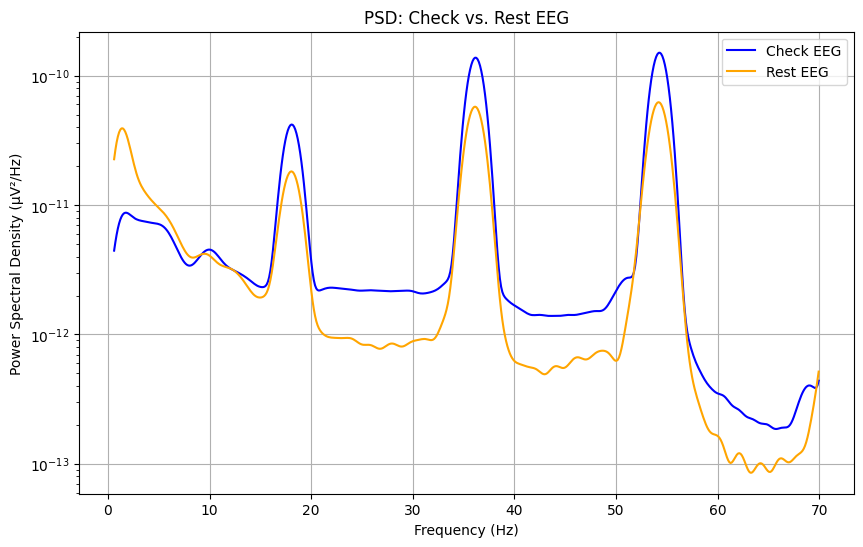

In [20]:
# Plot PSD
plt.figure(figsize=(10, 6))
plt.semilogy(freqs, psd_check_mean, label='Check EEG', color='blue')
plt.semilogy(freqs, psd_rest_mean, label='Rest EEG', color='orange')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power Spectral Density (µV²/Hz)')
plt.title('PSD: Check vs. Rest EEG')
plt.legend()
plt.grid(True)
plt.show()

**Overall spectrum shape and power** in both check and rest data shows a gradual decline in power from low to high frequencies, typical for EEG data due to the 1/f power law (power decreases inversely with frequency).


**Alpha Band (8–12 Hz)** The rest condition has higher alpha power, typical of a relaxed state (possibly eyes-closed), where alpha rhythms are prominent. The check condition shows alpha suppression, expected during a visual task (e.g., checkerboard stimuli), as the brain engages in visual processing, reducing alpha activity.

**Low Frequencies (Delta: 0.5–4 Hz, Theta: 4–8 Hz)** They are nearly identical between check and rest, suggesting that ocular artifact removal was effective, as there is no excessive delta power. 

**Beta Band (12–30 Hz)** The increased beta power in check suggests task-related cognitive engagement, such as visual attention or processing of the checkerboard stimuli. Rest, with minimal cognitive demands, shows lower beta activity.

**General EEG frequency information**

- The alpha rhythm is present over the posterior regions of the head during **wakefulness**, while the beta rhythm is prominent anteriorly. We will explore these facts using topography and spectrum line plots.

- In **drowsiness state** there is a decrease in frequency or persistence of the alpha rhythm, increased slower frequencies (theta and delta), and often an increase in beta frequencies anteriorly.


#### 3-Topography (all channels)

Effective window size : 8.192 (s)
Averaging across epochs before plotting...


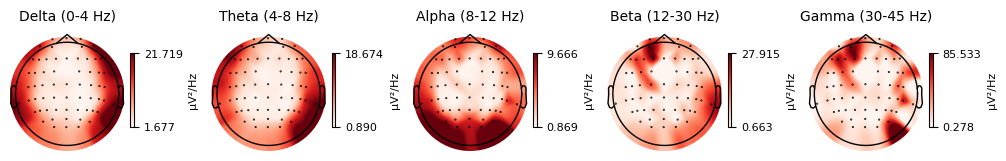

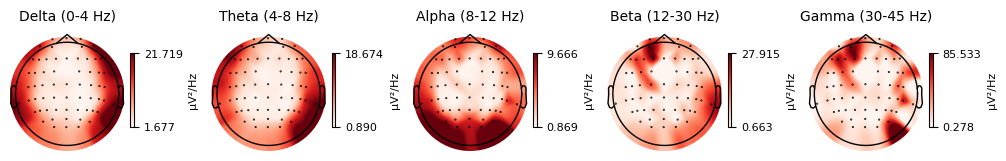

In [35]:
#check data
c_epochs_clean_sub.compute_psd(
    method="welch",
    fmin=0.5,
    fmax=70.0,
    picks="eeg",
    exclude="bads",
    n_fft=2048,  # Keep for better frequency resolution
    n_per_seg=176,  # Set to match n_times, enables zero-padding
    n_jobs=1
).plot_topomap(ch_type="eeg", normalize=False, contours=0)

The topography shows that alph frequency is more prominent posteriorly and the beta freqency is more prominent anteriorly

#### 4- Domain Frequency Analysis (occipital channels)

Effective window size : 8.192 (s)
Effective window size : 8.192 (s)


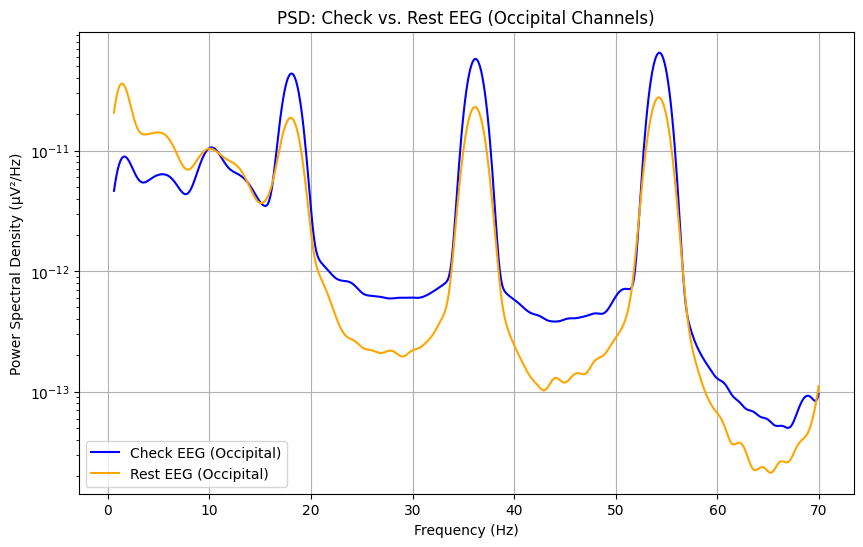

In [26]:
# Define occipital channels
occipital_channels = ['Oz', 'O1', 'O2'] 

# Compute PSD with zero-padding
psd_check_occipital = c_epochs_clean_sub.compute_psd(
    method="welch",
    fmin=0.5,
    fmax=70.0,
    picks=occipital_channels,
    exclude="bads",
    n_fft=2048,  # Keep for better frequency resolution
    n_per_seg=176,  # Set to match n_times, enables zero-padding
    n_jobs=1
)

psd_rest_occipital = r_epochs_clean_sub.compute_psd(
    method="welch",
    fmin=0.5,
    fmax=70.0,
    picks=occipital_channels,
    exclude="bads",
    n_fft=2048,
    n_per_seg=176,
    n_jobs=1
)

# Extract PSD data and frequencies
psd_check_data = psd_check_occipital.get_data()
psd_rest_data = psd_rest_occipital.get_data()
freqs = psd_check_occipital.freqs

# Average PSD across epochs and channels
psd_check_mean = psd_check_data.mean(axis=(0, 1))
psd_rest_mean = psd_rest_data.mean(axis=(0, 1))

# Plot PSD
plt.figure(figsize=(10, 6))
plt.semilogy(freqs, psd_check_mean, label='Check EEG (Occipital)', color='blue')
plt.semilogy(freqs, psd_rest_mean, label='Rest EEG (Occipital)', color='orange')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power Spectral Density (µV²/Hz)')
plt.title('PSD: Check vs. Rest EEG (Occipital Channels)')
plt.legend()
plt.grid(True)
plt.show()

The power of alpha rhythm shows an increase in the occipital channels as expected.

Next, we **compare** the alpha power at the peak frequency between the task and the rest states using **Independent t-test** and **Wilcoxon test**

In [24]:
from scipy.stats import ttest_ind, wilcoxon

# Find the frequency bin closest to 10 Hz
peak_freq_idx = np.argmin(np.abs(freqs - 10))
print(f"Peak frequency: {freqs[peak_freq_idx]} Hz")

# Extract alpha power at the peak frequency
alpha_power_check_peak = psd_check_data[:, :, peak_freq_idx]  # Shape: (n_epochs, n_channels)
alpha_power_rest_peak = psd_rest_data[:, :, peak_freq_idx]

# Average alpha power across channels at the peak frequency
alpha_power_check_avg = alpha_power_check_peak.mean(axis=1)  # Shape: (n_epochs,)
alpha_power_rest_avg = alpha_power_rest_peak.mean(axis=1)

# Independent t-test
t_stat, p_val = ttest_ind(alpha_power_check_avg, alpha_power_rest_avg)
print(f"T-test p-value ({freqs[peak_freq_idx]} Hz): {p_val:.4f}")

# Wilcoxon test (non-parametric, requires equal sample sizes)
# Subsample rest to match check's number of epochs
min_epochs = min(len(alpha_power_check_avg), len(alpha_power_rest_avg))
alpha_power_check_sub = alpha_power_check_avg[:min_epochs]
alpha_power_rest_sub = alpha_power_rest_avg[:min_epochs]
stat, p_val = wilcoxon(alpha_power_check_sub, alpha_power_rest_sub)
print(f"Wilcoxon p-value ({freqs[peak_freq_idx]} Hz): {p_val:.4f}")

Peak frequency: 10.009765625 Hz
T-test p-value (10.009765625 Hz): 0.9141
Wilcoxon p-value (10.009765625 Hz): 0.0292


**Results Interpretation**

The alpha power at 10.01 Hz is significantly higher in the rest condition compared to the check, as confirmed by the Wilcoxon test (p=0.0292). This reflects alpha suppression in the check condition, a common response to visual stimuli.

The t-test result can be discounted in favor of the Wilcoxon test, as the t-test is sensitive to variance, and with unequal sample sizes.





#### 5- Domain Frequency Analysis (occipital channels)

In [30]:
# Define frontal channels
frontal_channels = ['Fz', 'F1', 'F2']  

# Compute PSD for check data (frontal channels)
psd_check_frontal = c_epochs_clean_sub.compute_psd(
    method="welch",
    fmin=0.5,
    fmax=70.0,
    picks=frontal_channels,
    exclude="bads",
    n_jobs=1
)

# Compute PSD for rest data (frontal channels)
psd_rest_frontal = r_epochs_clean_sub.compute_psd(
    method="welch",
    fmin=0.5,
    fmax=70.0,
    picks=frontal_channels,
    exclude="bads",
    n_jobs=1
)

# Extract PSD data and frequencies
psd_check_data = psd_check_frontal.get_data()  # Shape: (n_epochs, n_channels, n_freqs)
psd_rest_data = psd_rest_frontal.get_data()
freqs = psd_check_frontal.freqs  # Frequencies are the same for both

# Average PSD across epochs and channels
psd_check_mean = psd_check_data.mean(axis=(0, 1))  # Average over epochs and channels
psd_rest_mean = psd_rest_data.mean(axis=(0, 1))

Effective window size : 0.704 (s)
Effective window size : 0.704 (s)


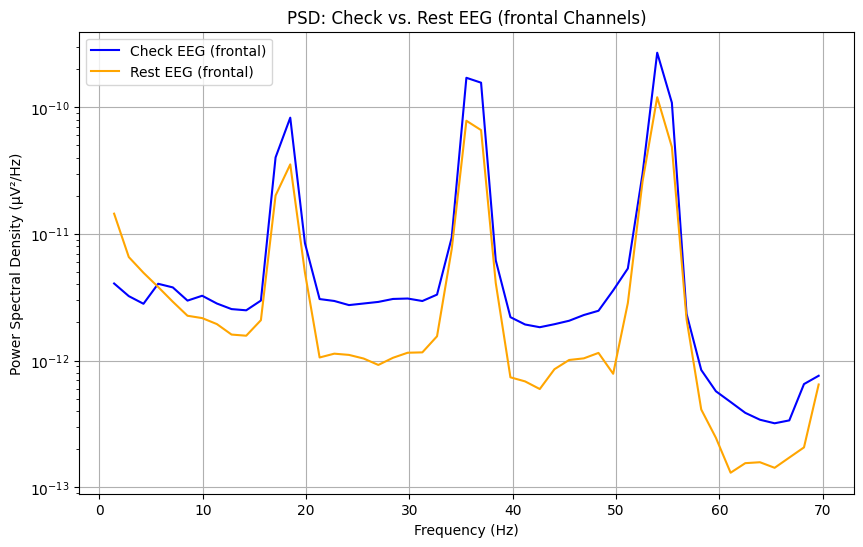

In [32]:
# Plot PSD using matplotlib
plt.figure(figsize=(10, 6))
plt.semilogy(freqs, psd_check_mean, label='Check EEG (frontal)', color='blue')
plt.semilogy(freqs, psd_rest_mean, label='Rest EEG (frontal)', color='orange')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power Spectral Density (µV²/Hz)')
plt.title('PSD: Check vs. Rest EEG (frontal Channels)')
plt.legend()
plt.grid(True)
plt.show()

The power of beta rhythm shows an increase in the occipital channels as expected.

Next, we **compare** the beta power at the peak frequency between the task and the rest states using **Independent t-test** and **Wilcoxon test**

In [36]:
# Find the frequency bin closest to 17 Hz
peak_freq_idx = np.argmin(np.abs(freqs - 17))
print(f"Peak frequency: {freqs[peak_freq_idx]} Hz")

# Extract alpha power at the peak frequency
alpha_power_check_peak = psd_check_data[:, :, peak_freq_idx]  # Shape: (n_epochs, n_channels)
alpha_power_rest_peak = psd_rest_data[:, :, peak_freq_idx]

# Average alpha power across channels at the peak frequency
alpha_power_check_avg = alpha_power_check_peak.mean(axis=1)  # Shape: (n_epochs,)
alpha_power_rest_avg = alpha_power_rest_peak.mean(axis=1)

# Independent t-test
t_stat, p_val = ttest_ind(alpha_power_check_avg, alpha_power_rest_avg)
print(f"T-test p-value ({freqs[peak_freq_idx]} Hz): {p_val:.4f}")

# Wilcoxon test (non-parametric, requires equal sample sizes)
# Subsample rest to match check's number of epochs
min_epochs = min(len(alpha_power_check_avg), len(alpha_power_rest_avg))
alpha_power_check_sub = alpha_power_check_avg[:min_epochs]
alpha_power_rest_sub = alpha_power_rest_avg[:min_epochs]
stat, p_val = wilcoxon(alpha_power_check_sub, alpha_power_rest_sub)
print(f"Wilcoxon p-value ({freqs[peak_freq_idx]} Hz): {p_val:.4f}")

Peak frequency: 17.045454545454547 Hz
T-test p-value (17.045454545454547 Hz): 0.2476
Wilcoxon p-value (17.045454545454547 Hz): 0.0066


**Results Interpretation**

The alpha power at 17.05 Hz is significantly higher in the check condition compared to the rest, as confirmed by the Wilcoxon test (p=0.0066). This reflects beta activity in the check condition, a common response to visual stimuli.

The t-test result can be discounted in favor of the Wilcoxon test, as the t-test is sensitive to variance, and with unequal sample sizes.
